In [ ]:
!!pip install datasets

['Collecting datasets',
 '  Downloading datasets-3.3.0-py3-none-any.whl.metadata (19 kB)',
 'Requirement already satisfied: filelock in /usr/local/lib/python3.11/dist-packages (from datasets) (3.17.0)',
 'Requirement already satisfied: numpy>=1.17 in /usr/local/lib/python3.11/dist-packages (from datasets) (1.26.4)',
 'Requirement already satisfied: pyarrow>=15.0.0 in /usr/local/lib/python3.11/dist-packages (from datasets) (17.0.0)',
 'Collecting dill<0.3.9,>=0.3.0 (from datasets)',
 '  Downloading dill-0.3.8-py3-none-any.whl.metadata (10 kB)',
 'Requirement already satisfied: pandas in /usr/local/lib/python3.11/dist-packages (from datasets) (2.2.2)',
 'Requirement already satisfied: requests>=2.32.2 in /usr/local/lib/python3.11/dist-packages (from datasets) (2.32.3)',
 'Requirement already satisfied: tqdm>=4.66.3 in /usr/local/lib/python3.11/dist-packages (from datasets) (4.67.1)',
 'Collecting xxhash (from datasets)',
 '  Downloading xxhash-3.5.0-cp311-cp311-manylinux_2_17_x86_64.many

In [ ]:
########################################################
# 1. IMPORTING LIBRARIES
########################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# If you haven't downloaded NLTK stopwords/lemmatizer yet:
nltk.download('stopwords')
nltk.download('wordnet')

# Hugging Face datasets
from datasets import load_dataset

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
########################################################
# 2. LOAD DATA FROM HUGGING FACE
########################################################

# Load the entire dataset from Hugging Face.
# By default, this dataset might only have a 'train' split.
# We can specify `split='train'` to get the data.
dataset = load_dataset('damerajee/IMDB-sentiment-reviews', split='train')

# Convert the Hugging Face dataset to a Pandas DataFrame
df = pd.DataFrame(dataset)

# Let's take only 100 samples for demonstration (you can remove this line to use the full dataset)
df = df.sample(n=100, random_state=42).reset_index(drop=True)

# Check the top rows
print("Sample data:")
print(df.head())

# Basic info
print("\nDataset info:")
print(df.info())

# The dataset should have columns: 'review' (text) and 'sentiment' (label)
print("\nValue counts for 'sentiment':")
print(df['sentiment'].value_counts())


README.md:   0%|          | 0.00/399 [00:00<?, ?B/s]

IMDB_Dataset%5B1%5D.csv:   0%|          | 0.00/66.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Sample data:
                                              review sentiment
0  I really liked this Summerslam due to the look...  positive
1  Not many television shows appeal to quite as m...  positive
2  The film quickly gets to a major chase scene w...  negative
3  Jane Austen would definitely approve of this o...  positive
4  Expectations were somewhat high for me when I ...  negative

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     100 non-null    object
 1   sentiment  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB
None

Value counts for 'sentiment':
sentiment
positive    52
negative    48
Name: count, dtype: int64


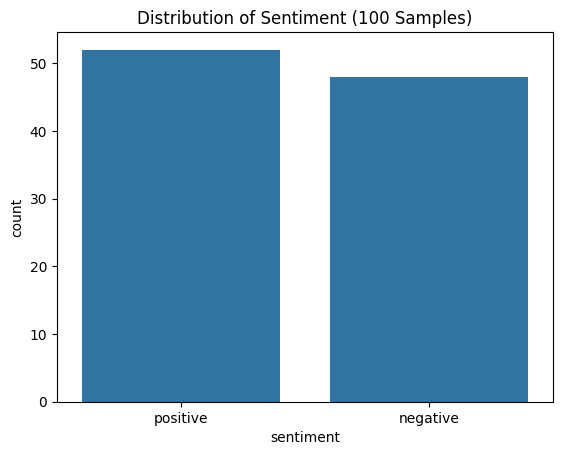

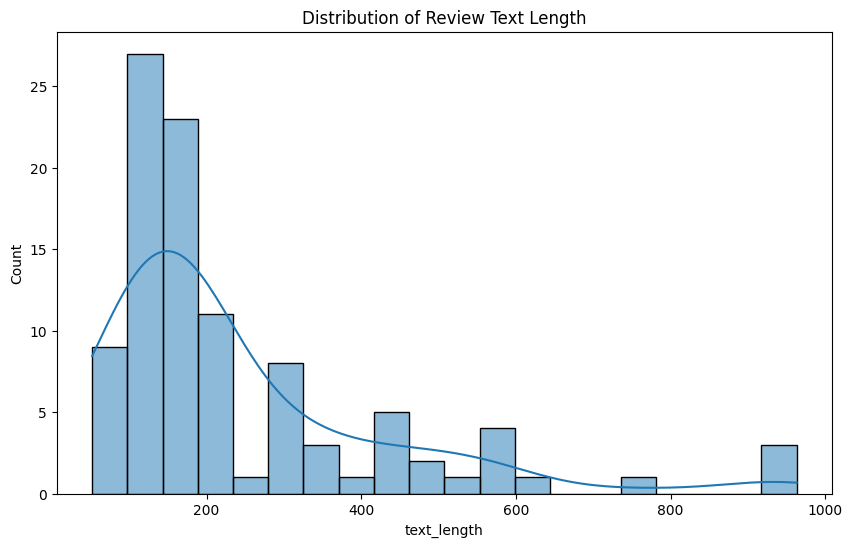

In [ ]:
########################################################
# 3. EXPLORATORY DATA ANALYSIS (OPTIONAL)
########################################################

# Plot distribution of sentiment
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiment (100 Samples)")
plt.show()

# Check distribution of text lengths
df['text_length'] = df['review'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,6))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title("Distribution of Review Text Length")
plt.show()

In [ ]:
########################################################
# 4. TEXT PREPROCESSING
########################################################

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text,
                    remove_stopwords=True,
                    use_stemming=False,
                    use_lemmatization=True):
    """
    Convert text to lowercase, remove non-alphabetic chars, remove stopwords,
    and optionally stem or lemmatize tokens.
    """
    # Lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z]', ' ', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]
    # Stemming
    if use_stemming:
        tokens = [stemmer.stem(word) for word in tokens]
    # Lemmatization
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Inspect results
print("\nOriginal vs Cleaned Review (first 3 rows):")
print(df[['review', 'cleaned_review']].head(3))



Original vs Cleaned Review (first 3 rows):
                                              review  \
0  I really liked this Summerslam due to the look...   
1  Not many television shows appeal to quite as m...   
2  The film quickly gets to a major chase scene w...   

                                      cleaned_review  
0  really liked summerslam due look arena curtain...  
1  many television show appeal quite many differe...  
2  film quickly get major chase scene ever increa...  


In [ ]:
########################################################
# 5. TRAIN-TEST SPLIT
########################################################

X = df['cleaned_review']
y = df['sentiment']

# We’ll split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # helps preserve class balance
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")



Training set size: 80
Testing set size:  20


In [ ]:
########################################################
# 6. FEATURE EXTRACTION (TF-IDF)
########################################################

# TF-IDF vectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
X_train_tfidf

<80x3652 sparse matrix of type '<class 'numpy.float64'>'
	with 8121 stored elements in Compressed Sparse Row format>

In [ ]:
########################################################
# 7. TRAINING LOGISTIC REGRESSION
########################################################

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)


----- Logistic Regression Evaluation -----
Accuracy: 0.8
Classification Report:
               precision    recall  f1-score   support

    negative       0.88      0.70      0.78        10
    positive       0.75      0.90      0.82        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



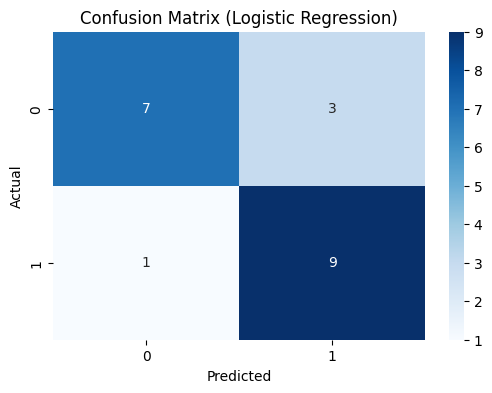

In [ ]:
########################################################
# 8. EVALUATION ON TEST SET
########################################################

y_pred = model.predict(X_test_tfidf)

print("\n----- Logistic Regression Evaluation -----")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
########################################################
# 9. INFERENCE ON NEW TEXT EXAMPLE
########################################################

def predict_sentiment(text, model, vectorizer):
    """
    Preprocess incoming text, transform it using the given vectorizer,
    and predict sentiment using the trained model.
    """
    cleaned = preprocess_text(text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)
    return prediction[0]

# Example usage
new_review = (
    "This movie was absolutely fantastic! The story kept me hooked and the acting was brilliant."
)
predicted_label = predict_sentiment(new_review, model, tfidf)
print(f"\nNew Review: {new_review}")
print(f"Predicted Sentiment: {predicted_label}")


New Review: This movie was absolutely fantastic! The story kept me hooked and the acting was brilliant.
Predicted Sentiment: positive
